[Index](Index.ipynb) - [Prev](CNOT_gate.ipynb) - [Next](Random_number.ipynb)

### SWAP gate <a id='swap'></a>

Sometimes we need to move information around in a quantum computer. For some qubit implementations, this could be done by physically moving them. Another option is simply to move the state between two qubits. This is done using the SWAP gate.



total counts are: {'0010': 1024}


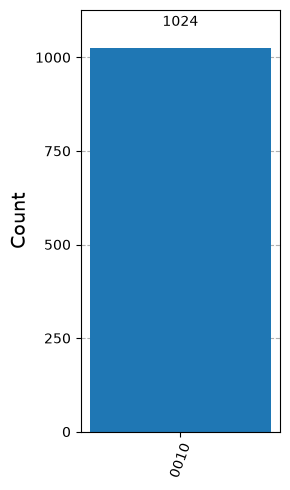

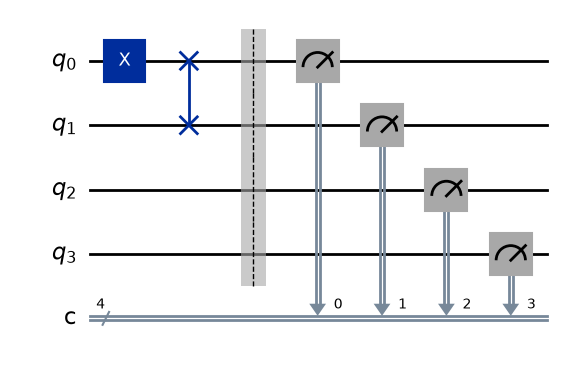

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer.primitives import SamplerV2
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes

#define circuit with four qubits and a register with four classical bits
q = QuantumRegister(4, 'q')
c = ClassicalRegister(4, 'c')
circuit = QuantumCircuit(q,c)


# Using an X gate to define initial state of qubit q0 to be alpha=0, beta=1 --> state |1000>
circuit.x(0)

circuit.swap(0,1) 

# ---- Add extra gates to execute on qubit here----

# visually separate the gates from the measurement
circuit.barrier(q)

circuit.measure(q, c)

# define simulator
sampler = SamplerV2()
# execute the circuit with this simulator
job = sampler.run([circuit]).result()
counts = job[0].data.c.get_counts()

print ("total counts are:",counts)
# plot histogram
display(plot_histogram(counts,figsize=(3,5)))

# show circuit
display(circuit.draw(output='mpl'))

The swap gate changes the state of qubit $q_0$ and $q_1$. Initially $q_0$ was in state $|1\rangle$ and $q_1$ in state $|0\rangle$. The total state of the system was $|1000\rangle$. The swap gate changes the state of $q_0 \mapsto q_1$ which was $|0\rangle$ and the state of $q_1 \mapsto q_0$ which was $|1\rangle$. The total state of the system is now therefore $|0100\rangle$.

> E1: Initialize q0 and q1 in state $|1\rangle$. What is the total state of the system? 

> E2: Starting from the initial state above, how can you get to state $|0110\rangle$? Which qubits need to be swapped?

> E3: Assume you can only swap with the qubits next to you, how do we move information from q0 to q4?